# 🗂️ Mini Model Registry

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ml-engineering-toolkit/model-registry/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ml-engineering-toolkit/model-registry/demo.ipynb)

> "Which model is actually in production?" should have a one-word answer.

**Pain point:** *"We lose track of model versions."* This notebook walks through a tiny, file-backed model registry: versioned artifacts, a JSON metadata index, content hashing, and stage promotion with a single-production-per-model invariant.

## Table of contents
1. [Setup](#1-setup)
2. [A tiny registry (standalone)](#2-a-tiny-registry-standalone)
3. [Register 3 model versions](#3-register-3-model-versions)
4. [List them as a table](#4-list-them-as-a-table)
5. [Promote the best to production](#5-promote-the-best-to-production)
6. [Chart: metric per version](#6-chart-metric-per-version)
7. [Try your own](#7-try-your-own)


## 1. Setup

In [1]:
from __future__ import annotations

import hashlib
import io
import json
import os
import tempfile
from typing import Optional, List, Dict

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

print('ready')

ready


## 2. A tiny registry (standalone)

The class below duplicates the core logic of `registry.py` so this notebook runs standalone (nothing to import). It stores artifacts under a temp dir and keeps a JSON index of version records.

In [2]:
VALID_STAGES = ("staging", "production", "archived")


class Registry:
    """Minimal file-backed model registry (standalone copy for the demo)."""

    def __init__(self, root: str) -> None:
        self.root = root
        self.artifacts_dir = os.path.join(root, "artifacts")
        self.index_path = os.path.join(root, "index.json")
        os.makedirs(self.artifacts_dir, exist_ok=True)
        if not os.path.exists(self.index_path):
            self._write_index([])

    def _read_index(self) -> List[Dict]:
        with open(self.index_path, "r", encoding="utf-8") as fh:
            return json.load(fh)

    def _write_index(self, records: List[Dict]) -> None:
        with open(self.index_path, "w", encoding="utf-8") as fh:
            json.dump(records, fh, indent=2)

    def _artifact_path(self, name: str, version: int) -> str:
        return os.path.join(self.artifacts_dir, name, f"v{version}.joblib")

    def register(self, name: str, model: object, metrics: Dict,
                 params: Optional[Dict] = None,
                 created_at: Optional[str] = None) -> Dict:
        records = self._read_index()
        existing = [r for r in records if r["name"] == name]
        version = max((r["version"] for r in existing), default=0) + 1
        buffer = io.BytesIO()
        joblib.dump(model, buffer)
        payload = buffer.getvalue()
        content_hash = hashlib.sha256(payload).hexdigest()[:12]
        artifact_path = self._artifact_path(name, version)
        os.makedirs(os.path.dirname(artifact_path), exist_ok=True)
        with open(artifact_path, "wb") as fh:
            fh.write(payload)
        record: Dict = {
            "name": name, "version": version, "stage": "staging",
            "hash": content_hash, "metrics": dict(metrics),
            "params": dict(params) if params else {},
            "created_at": created_at,
        }
        records.append(record)
        self._write_index(records)
        return record

    def list_models(self, name: Optional[str] = None) -> List[Dict]:
        records = self._read_index()
        if name is not None:
            records = [r for r in records if r["name"] == name]
        return records

    def get(self, name: str, version: Optional[int] = None) -> Dict:
        records = [r for r in self._read_index() if r["name"] == name]
        if not records:
            raise KeyError(f"No model named {name!r}")
        if version is None:
            return max(records, key=lambda r: r["version"])
        for r in records:
            if r["version"] == version:
                return r
        raise KeyError(f"No version {version} for {name!r}")

    def load_model(self, name: str, version: Optional[int] = None) -> object:
        record = self.get(name, version)
        return joblib.load(self._artifact_path(name, record["version"]))

    def promote(self, name: str, version: int, stage: str) -> Dict:
        if stage not in VALID_STAGES:
            raise ValueError(f"bad stage {stage!r}")
        records = self._read_index()
        target: Optional[Dict] = None
        for r in records:
            if r["name"] == name and r["version"] == version:
                target = r
                break
        if target is None:
            raise KeyError(f"No version {version} for {name!r}")
        if stage == "production":
            for r in records:
                if (r["name"] == name and r["stage"] == "production"
                        and r["version"] != version):
                    r["stage"] = "archived"
        target["stage"] = stage
        self._write_index(records)
        return target

    def best(self, name: str, metric: str,
             higher_is_better: bool = True) -> Dict:
        records = [r for r in self._read_index()
                   if r["name"] == name and metric in r["metrics"]]
        if not records:
            raise KeyError(f"No versions of {name!r} with {metric!r}")
        return (max if higher_is_better else min)(
            records, key=lambda r: r["metrics"][metric])

    def to_frame(self) -> pd.DataFrame:
        rows: List[Dict] = []
        for r in self._read_index():
            row: Dict = {"name": r["name"], "version": r["version"],
                         "stage": r["stage"], "hash": r["hash"],
                         "created_at": r["created_at"]}
            row.update(r["metrics"])
            rows.append(row)
        return pd.DataFrame(rows)

reg = Registry(tempfile.mkdtemp(prefix="nb_registry_"))
print("registry root:", reg.root)

registry root: /var/folders/zf/9y5vgz8x1_72sv6fq_wkfksr0000gr/T/nb_registry_tsp9qf9p


## 3. Register 3 model versions

Train three logistic-regression models with different regularization `C`, then register each. Every registration gets an auto-incremented version and a content hash of the exact serialized bytes.

In [3]:
X, y = make_classification(n_samples=600, n_features=20,
                           n_informative=8, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

for i, C in enumerate([0.01, 1.0, 10.0], start=1):
    model = LogisticRegression(C=C, max_iter=1000).fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]
    preds = model.predict(X_te)
    metrics = {
        "auc": round(float(roc_auc_score(y_te, proba)), 4),
        "accuracy": round(float(accuracy_score(y_te, preds)), 4),
    }
    rec = reg.register("churn_clf", model, metrics=metrics,
                       params={"C": C},
                       created_at=f"2026-07-17T09:0{i}:00")
    print(f"v{rec['version']}  hash={rec['hash']}  metrics={metrics}")

v1  hash=7d88bfc1e55b  metrics={'auc': 0.8771, 'accuracy': 0.7944}
v2  hash=c04ad19a7aa2  metrics={'auc': 0.877, 'accuracy': 0.8}
v3  hash=93cf776c824f  metrics={'auc': 0.8771, 'accuracy': 0.8}


## 4. List them as a table

All three versions start in the `staging` stage.

In [4]:
reg.to_frame()

,name,version,stage,hash,created_at,auc,accuracy
0,churn_clf,1,staging,7d88bfc1e55b,2026-07-17T09:01:00,0.8771,0.7944
1,churn_clf,2,staging,c04ad19a7aa2,2026-07-17T09:02:00,0.8770,0.8000
2,churn_clf,3,staging,93cf776c824f,2026-07-17T09:03:00,0.8771,0.8000


## 5. Promote the best to production

Pick the best version by AUC and promote it. Then we promote a second version to show the invariant in action: promoting a new production version **auto-archives** the previous one - only one production version ever.

In [5]:
winner = reg.best("churn_clf", "auc", higher_is_better=True)
print(f"best by auc -> v{winner['version']} (auc={winner['metrics']['auc']})")
reg.promote("churn_clf", winner["version"], "production")
reg.to_frame()

best by auc -> v1 (auc=0.8771)


,name,version,stage,hash,created_at,auc,accuracy
0,churn_clf,1,production,7d88bfc1e55b,2026-07-17T09:01:00,0.8771,0.7944
1,churn_clf,2,staging,c04ad19a7aa2,2026-07-17T09:02:00,0.8770,0.8000
2,churn_clf,3,staging,93cf776c824f,2026-07-17T09:03:00,0.8771,0.8000


In [6]:
# Promote a different version -> previous production is auto-archived.
other = [r['version'] for r in reg.list_models('churn_clf')
         if r['version'] != winner['version']][0]
reg.promote('churn_clf', other, 'production')
frame = reg.to_frame()
prod = [r for r in reg.list_models('churn_clf') if r['stage'] == 'production']
assert len(prod) == 1, 'invariant broken!'
print(f"single-production invariant holds: exactly 1 production (v{prod[0]['version']})")
frame

single-production invariant holds: exactly 1 production (v2)


,name,version,stage,hash,created_at,auc,accuracy
0,churn_clf,1,archived,7d88bfc1e55b,2026-07-17T09:01:00,0.8771,0.7944
1,churn_clf,2,production,c04ad19a7aa2,2026-07-17T09:02:00,0.8770,0.8000
2,churn_clf,3,staging,93cf776c824f,2026-07-17T09:03:00,0.8771,0.8000


## 6. Chart: metric per version

Bar chart of AUC per version, with the current **production** version highlighted in green.

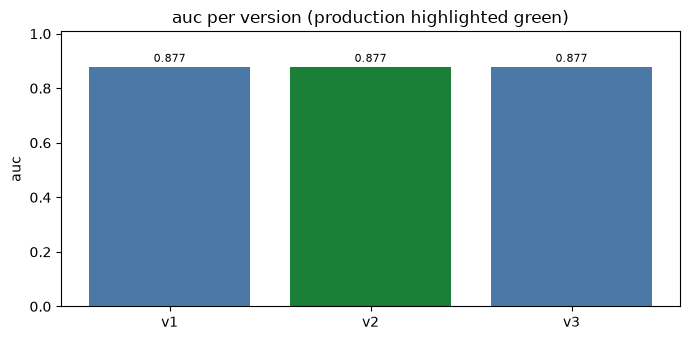

In [7]:
frame = reg.to_frame().sort_values('version')
metric = 'auc'
colors = ['#1a7f37' if s == 'production' else '#4c78a8' for s in frame['stage']]
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar([f"v{v}" for v in frame['version']], frame[metric], color=colors)
ax.set_ylabel(metric)
ax.set_ylim(0, max(1.0, float(frame[metric].max()) * 1.15))
ax.set_title(f'{metric} per version (production highlighted green)')
for bar, val in zip(bars, frame[metric]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 7. Try your own

Uncomment and adapt the cell below to register your own model.

In [8]:
# from sklearn.ensemble import RandomForestClassifier
# my_model = RandomForestClassifier(n_estimators=50, random_state=0).fit(X_tr, y_tr)
# my_metrics = {'auc': round(float(roc_auc_score(
#     y_te, my_model.predict_proba(X_te)[:, 1])), 4)}
# rec = reg.register('churn_clf', my_model, metrics=my_metrics,
#                    params={'model': 'rf'})
# print(rec)
# reg.to_frame()

---

Built by Phoebe Fu -> [github.com/phoebefu6/phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)